In [ ]:
# Visualisation of the classification dataset (Fig 2.a) and Appendix A1


In [7]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
from config1 import CLASSIFICATION_DATA


In [8]:
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
p_df = CLASSIFICATION_DATA / "1.IMAGES_classification"

In [11]:
my_list=[]
li=[]
for root, _, files in os.walk(p_df):
    for file in files:
        classi = root.split("/")[-1]
        if file.lower().endswith('.jpg'):
            li+=[[classi, file.split("_")[0], 1]]
            my_list+=[file.split("_")[0]]

print(Counter(my_list))

df= pd.DataFrame(li, columns=["classe",  "source", "count" ])
df = df.groupby(["classe", "source"], as_index=False).sum()
df

Counter({'ref': 39146, 'env': 12540})


,classe,source,count
0,Acacia,env,1
1,Acacia,ref,49
2,Acer,env,89
3,Acer,ref,842
4,Alnus,env,105
...,...,...,...
96,VitisF,ref,1428
97,VitisS,env,183
98,VitisS,ref,1030
99,XanthiumAmbrosia,env,34


In [12]:
# total number of images per image type
print(len(list(set(df["classe"]))))
print(sorted(list(set(df["classe"]))))
df0 = df[["source", "count"]].groupby(["source"], as_index=False).sum()
df0

54
['Acacia', 'Acer', 'Alnus', 'Amarantaceae', 'Artemisia', 'Betulaceae', 'Brassicaceae', 'Buxus', 'Carduus', 'Caryophyllaceae', 'Cichorioideae', 'Cupressaceae', 'Cyperaceae', 'Echium', 'Ericaceae', 'Fagus', 'FraxinusExcelsior', 'FraxinusOrnus', 'Gallium', 'IndetBlurry', 'IndetCovered', 'Juglans', 'Lamiaceae', 'Liliaceae', 'Lycopodium', 'Moraceae', 'Morphotype1_smallgrains', 'Morphotype2_largegrains', 'Myrtaceae', 'NonPollen', 'Olea', 'Other', 'Phillyrea', 'Pinaceae', 'Pistacia', 'Plantago', 'Platanus', 'Poaceae', 'PopulusSp', 'QuercusDeciduous', 'QuercusIlex', 'Ranunculaceae', 'Rhamnus', 'Rosaceae', 'Rumex', 'Salix', 'Sanguisorba', 'Tilia', 'Ulmus', 'Urtica', 'ViburnumSambucusTp', 'VitisF', 'VitisS', 'XanthiumAmbrosia']


,source,count
0,env,12540
1,ref,39146


In [13]:
df_wide = df.pivot_table(index='classe', columns='source', values='count', fill_value=0)

df_wide = df_wide.rename(columns={'env': 'nb_env', 'ref': 'nb_ref'}).reset_index()

df_wide['count'] = df_wide['nb_env'] + df_wide['nb_ref']
df_wide[['nb_env', 'nb_ref', 'count']] = df_wide[['nb_env', 'nb_ref', 'count']].astype(int)

df_sorted = df_wide.sort_values(by='count', ascending=False)
print(len(sorted(list(df_sorted["classe"]))))
df_sorted.head()


54


source,classe,nb_env,nb_ref,count
5,Betulaceae,196,1804,2000
3,Amarantaceae,81,1919,2000
11,Cupressaceae,914,1086,2000
37,Poaceae,956,1044,2000
32,Phillyrea,263,1737,2000


In [14]:
li_cl = ['Acacia', 'Acer', 'Alnus', 'Amarantaceae', 'Artemisia', 'Betulaceae', 'Brassicaceae', 'Buxus', 'Carduus',
          'Caryophyllaceae', 'Cichorioideae', 'Cupressaceae', 'Cyperaceae', 'Echium', 'Ericaceae', 'Fagus', 'FraxinusExcelsior', 
          'FraxinusOrnus', 'Gallium', 'IndetBlurry', 'IndetCovered', 'Juglans', 'Lamiaceae', 'Liliaceae', 'Lycopodium', 'Moraceae',
            'Morphotype1', 'Morphotype2', 'Myrtaceae', 'NonPollen', 'Olea', 'Other', 'Phillyrea', 'Pinaceae', 'Pistacia', 'Plantago', 
            'Platanus', 'Poaceae', 'PopulusSp', 'QuercusDeciduous', 'QuercusIlex', 'Ranunculaceae', 'Rhamnus', 'Rosaceae', 'Rumex', 'Salix',
              'Sanguisorba', 'Tilia', 'Ulmus', 'Urtica', 'ViburnumSambucusTp', 'VitisF', 'VitisS', 'XanthiumAmbrosia']

name_mapping_it = { 
    'Acacia': r'$\it{Acacia}$', 'Acer': r'$\it{Acer}$', 'Alnus': r'$\it{Alnus}$',
    'Amarantaceae': 'Amarantaceae', 'Artemisia': r'$\it{Artemisia}$', 'Betulaceae': r'$\it{Betulaceae}$',
    'Brassicaceae': 'Brassicaceae', 'Buxus': r'$\it{Buxus}$',
    'Carduus': r'$\it{Carduus}$',  'Caryophyllaceae': 'Caryophyllaceae',
    'Cichorioideae': 'Cichorioideae',
   'Cupressaceae': r'$\it{Cupressaceae}$', 'Cyperaceae': 'Cyperaceae',
    'Echium': r'$\it{Echium}$', 'Ericaceae': 'Ericaceae', 'Fagus': r'$\it{Fagus}$', 'FraxinusExcelsior': r'$\it{Fraxinus~excelsior}$',
    'FraxinusOrnus': r'$\it{Fraxinus~ornus}$', 'Gallium': r'$\it{Galium}$', 
    'Helianthemum': r'$\it{Helianthemum}$', 'Hypericum': r'$\it{Hypericum}$', 'IlexAquifolium': r'$\it{Ilex~aquifolium}$',
    'IndetBlurry': 'Indeterminate (blurry)', 'IndetCovered': 'Indeterminate (covered)',
    'Juglans': r'$\it{Juglans}$', 'Lamiaceae': 'Lamiaceae','Liliaceae': 'Liliaceae',  'Lycopodium': r'$\it{Lycopodium}$',
    'Moraceae': 'Moraceae', 'Morphotype1' : 'Morphotype 1', 'Morphotype2' : "Morphotype 2", 
    'Myrtaceae': 'Myrtaceae', 'NonPollen': 'Non-pollen', 'Olea': r'$\it{Olea}$',
    'Other': 'Other taxa', 'Phillyrea': r'$\it{Phillyrea}$',
    'Pinaceae': 'Pinaceae', 'Pistacia': r'$\it{Pistacia}$', 'Plantago': r'$\it{Plantago}$',
    'Platanus': r'$\it{Platanus}$', 'Poaceae': 'Poaceae', 'PopulusSp': r'$\it{Populus}$',
    'QuercusDeciduous': r'$\it{Quercus~deciduous}$', 'QuercusIlex': r'$\it{Quercus~ilex}$',
    'Ranunculaceae': 'Ranunculaceae', 'Rhamnus': r'$\it{Rhamnus}$', 'Rosaceae': 'Rosaceae',
    'Rumex': r'$\it{Rumex}$', 'Salix': r'$\it{Salix}$', 'Sanguisorba': r'$\it{Sanguisorba}$',
    'Tilia': r'$\it{Tilia}$', 'Ulmus': r'$\it{Ulmus}$', 'Urtica': r'$\it{Urtica}$',
    "ViburnumSambucusTp" : r'$\it{Viburnum / Sambucus}$',
    'VitisF': r'$\it{Vitis}$ fertile', 'VitisS': r'$\it{Vitis}$ sterile', 'XanthiumAmbrosia':  r'$\it{Xanthium / Ambrosia}$',
}


df_sorted['classe2'] = df_sorted['classe'].map(name_mapping_it)
df_sorted['classe2'] = df_sorted['classe2'].fillna(df_sorted['classe'])
df_sorted

df_sorted.head()

source,classe,nb_env,nb_ref,count,classe2
5,Betulaceae,196,1804,2000,$\it{Betulaceae}$
3,Amarantaceae,81,1919,2000,Amarantaceae
11,Cupressaceae,914,1086,2000,$\it{Cupressaceae}$
37,Poaceae,956,1044,2000,Poaceae
32,Phillyrea,263,1737,2000,$\it{Phillyrea}$


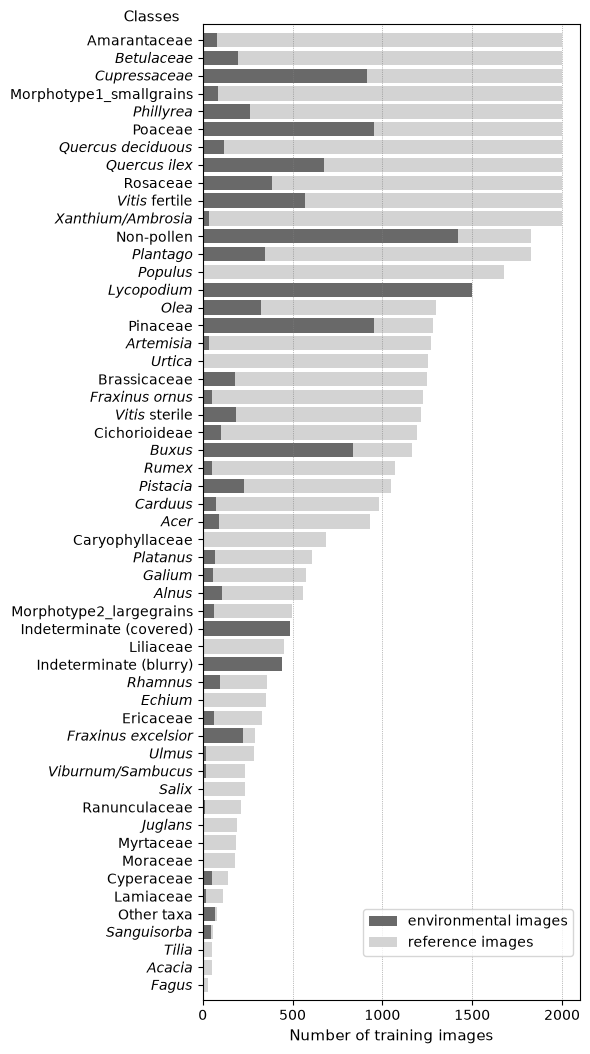

In [16]:
# Figure Supporting Information 

final_df = df_sorted.copy()

final_df = final_df.sort_values(by=['count', "classe"], ascending=[True, False])

plt.figure(figsize = (6, 10.5))
plt.barh(final_df['classe2'], final_df['nb_env'], color='dimgrey', label='environmental images')
plt.barh(final_df['classe2'], final_df['nb_ref'], left=final_df['nb_env'], color='lightgrey', label='reference images')

plt.xlabel('Number of training images', fontsize=11)
plt.ylabel('', labelpad=-5) 
plt.xticks(range(0, 2001, 500))
plt.legend(title='', bbox_to_anchor=(1,0.1))
plt.grid(axis='x', color='grey', linestyle=":", linewidth=0.5)
plt.yticks(size=10)


plt.text(-440, 54.7, 'Classes', va='top', ha='left', fontsize=11)
plt.grid(axis='x', color='grey', linestyle=":", linewidth=0.5)

plt.tight_layout() 
plt.ylim(-0.8, len(final_df['classe2']) - 0.1)

plt.show()

plt.close()

In [17]:
final_df = df_sorted.copy()


final_df = final_df.sort_values(by=['count', "classe"], ascending=[True, False])

target_classes = ['Buxus', 'Cupressaceae', 'FraxinusExcelsior', 'FraxinusOrnus', 'Olea',  'Phillyrea', 'Pinaceae', 'Pistacia', 'Plantago', 'Poaceae', 'QuercusDeciduous', 'QuercusIlex', 'VitisF', 'VitisS', 'IndetBlurry', 'IndetCovered', 'Lycopodium', 'NonPollen', ]


nontarget=[c for c in list(sorted(final_df['classe'])) if c not in target_classes]

df_target = final_df[final_df['classe'].isin(target_classes)]
df_nontarget = final_df[final_df['classe'].isin(nontarget)]
df_nontarget_sum = df_nontarget[['nb_env', 'nb_ref', 'count']].sum().to_frame().T
df_nontarget_sum['classe'] = 'Non-target taxa'
df_nontarget_sum['classe2'] = 'Non-target taxa'
df_concat = pd.concat([df_target, df_nontarget_sum], ignore_index=True)


# fraxinus
li_frax=['FraxinusExcelsior', 'FraxinusOrnus']
nonfrax=[c for c in list(sorted(df_concat['classe'])) if c not in li_frax]

df_nofrax = df_concat[df_concat['classe'].isin(nonfrax)]
df_fraxt = df_concat[df_concat['classe'].isin(li_frax)]
df_nontarget_sum2 = df_fraxt[['nb_env', 'nb_ref', 'count']].sum().to_frame().T

df_nontarget_sum2['classe'] = 'Fraxinus'
df_nontarget_sum2['classe2'] = r'$\it{Fraxinus}$'
df_concat2 = pd.concat([df_nofrax, df_nontarget_sum2], ignore_index=True)


df_concat2

source,classe,nb_env,nb_ref,count,classe2
0,IndetBlurry,440,0,440,Indeterminate (blurry)
1,IndetCovered,487,0,487,Indeterminate (covered)
2,Pistacia,230,816,1046,$\it{Pistacia}$
3,Buxus,837,330,1167,$\it{Buxus}$
4,VitisS,183,1030,1213,$\it{Vitis}$ sterile
5,Pinaceae,954,328,1282,Pinaceae
6,Olea,326,974,1300,$\it{Olea}$
7,Lycopodium,1499,0,1499,$\it{Lycopodium}$
8,Plantago,345,1480,1825,$\it{Plantago}$
9,NonPollen,1420,407,1827,Non-pollen


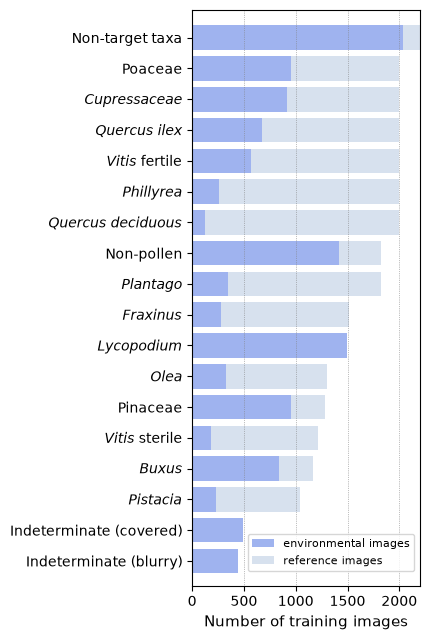

In [18]:


df_fig = df_concat2.sort_values(by=['count', 'nb_env', "classe"], ascending=[True, True, False])


plt.figure(figsize = (4.4, 6.5))
plt.barh(df_fig['classe2'], df_fig['nb_env'], color='royalblue', label='environmental images', alpha=0.5)
plt.barh(df_fig['classe2'], df_fig['nb_ref'], left=df_fig['nb_env'], color='lightsteelblue', label='reference images', alpha=0.5)

plt.xlabel('Number of training images', fontsize=11)
plt.ylabel('', labelpad=-5) 
plt.xticks(range(0, 2001, 500))
plt.legend(title='', bbox_to_anchor=(1,0.1), fontsize=8)
plt.grid(axis='x', color='grey', linestyle=":", linewidth=0.5)
plt.yticks(size=10)

plt.grid(axis='x', color='grey', linestyle=":", linewidth=0.5)

plt.tight_layout()
plt.ylim(-0.8, len(df_fig['classe2']) - 0.1)
plt.xlim(0,2200)


plt.show()

plt.close()

### Percentages and values

In [19]:
li_classes = list(set(df_sorted["classe"]))
nb_classes = len(li_classes)
tot_env = sum(list(df_sorted["nb_env"]))
tot_ref = sum(list(df_sorted["nb_ref"]))
tot = sum(list(df_sorted["count"]))

perc_env = tot_env*100/tot
perc_ref = tot_ref*100/tot

print(nb_classes, tot, perc_env, perc_ref, perc_ref+perc_env, tot_env, tot_ref)
# 54 51686 24.261889099562744 75.73811090043725 100.0 12540 39146

54 51686 24.261889099562744 75.73811090043725 100.0 12540 39146


In [ ]:
# end